In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv')

In [107]:

# Dataset Description

 
# The dataset used in this project represents customer behavior and insurance
# policy information, with the objective of predicting customer response(binary classification).

# Target Variable:(Response)
# - The target variable is binary (Yes / No), indicating customer response.
#  It was encoded into numerical form (0 / 1) to support machine learning models.

# Dimensionality:
# - The dataset contains a moderate number of features (mixed numerical and
#   categorical), making it suitable for testing feature selection techniques such as LASSO and K-Best.

# Why the Dataset is Interesting:
# - It reflects a real-world business scenario where class imbalance exists.
# - The mix of categorical and numerical features requires careful preprocessing.
# - It allows meaningful comparison between linear models, tree-based models,
#   instance-based models, and ensemble techniques.

# Overall, the dataset is well-suited for evaluating different machine learning
# models, feature selection strategies, and ensemble learning methods.



In [85]:
%pip install mlflow

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.9 MB 465.6 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/8.9 MB 465.6 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/8.9 MB 465.6 kB/s eta 0:00:19
   --- ------------------------------------ 0.8/8.9 MB 394.8 kB/s eta 0:00:21
   --- ------------------------------------ 0.8/8.9 MB 394.8 kB/s eta 0:00:21
   --- ------------------------------------ 0.8/8.9 MB 394.8 kB/s eta 0:00:21
   --- ------------------------------------ 0.8/8.9 MB 394.8 kB/s eta 0:00:21
   ---- --------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.33.2 which is incompatible.


In [2]:
df.isnull().sum()

Customer                         0
State                            0
Customer Lifetime Value          0
Response                         0
Coverage                         0
Education                        0
Effective To Date                0
EmploymentStatus                 0
Gender                           0
Income                           0
Location Code                    0
Marital Status                   0
Monthly Premium Auto             0
Months Since Last Claim          0
Months Since Policy Inception    0
Number of Open Complaints        0
Number of Policies               0
Policy Type                      0
Policy                           0
Renew Offer Type                 0
Sales Channel                    0
Total Claim Amount               0
Vehicle Class                    0
Vehicle Size                     0
dtype: int64

In [3]:

# Add Artificial Nulls (Pre-Splitting)
 # Missing Values and Outliers:
# - The dataset has either no missing values or a very small percentage, which
#   makes it clean and practical for supervised learning, so I added artfitial nulls and
# removed them after splitting

import random
random.seed(42)
np.random.seed(42)

cols_to_nullify = ['Income', 'Monthly Premium Auto', 'Total Claim Amount']
for col in cols_to_nullify:
    null_indices = df.sample(frac=0.05).index # 5% nulls
    df.loc[null_indices, col] = np.nan

print("Artificial nulls added to:", cols_to_nullify)
print("Null counts before split:\n", df.isnull().sum()[cols_to_nullify])

Artificial nulls added to: ['Income', 'Monthly Premium Auto', 'Total Claim Amount']
Null counts before split:
 Income                  457
Monthly Premium Auto    457
Total Claim Amount      457
dtype: int64


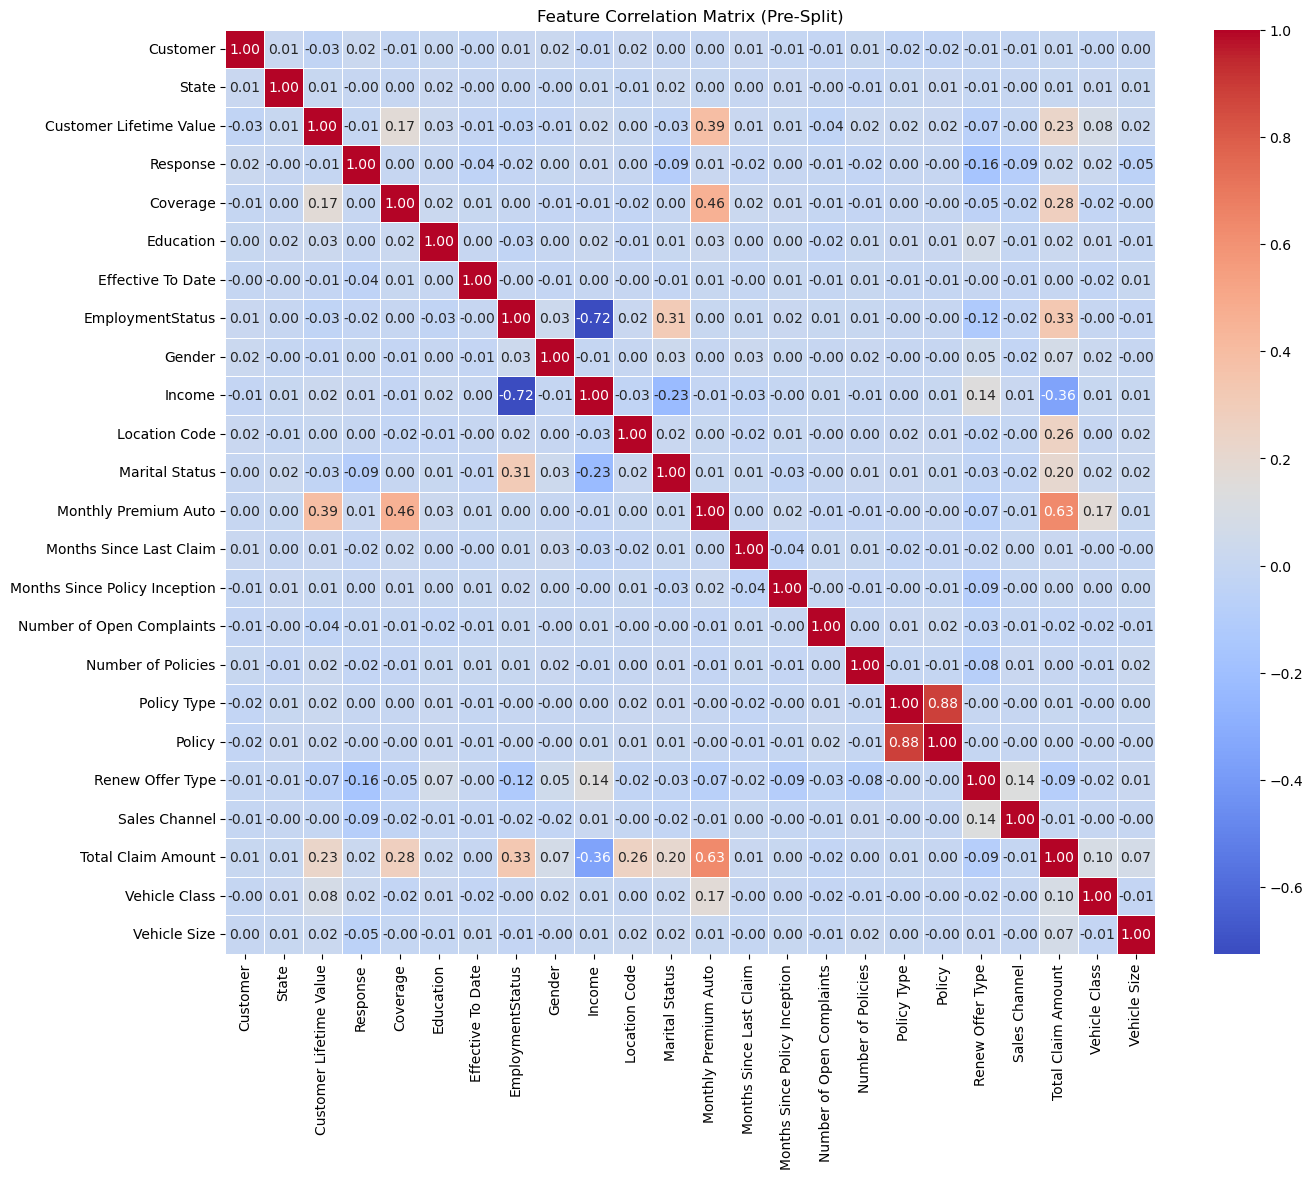

Correlation with 'Response':
 Response                         1.000000
Customer                         0.023256
Vehicle Class                    0.021225
Total Claim Amount               0.018806
Monthly Premium Auto             0.014183
Income                           0.012394
Gender                           0.004396
Months Since Policy Inception    0.002952
Location Code                    0.001729
Policy Type                      0.001110
Coverage                         0.000642
Education                        0.000285
Policy                          -0.001461
State                           -0.002473
Customer Lifetime Value         -0.008930
Number of Open Complaints       -0.009881
Months Since Last Claim         -0.016597
EmploymentStatus                -0.016703
Number of Policies              -0.020891
Effective To Date               -0.043133
Vehicle Size                    -0.050691
Sales Channel                   -0.086607
Marital Status                  -0.094843
Rene

In [4]:

# Correlation Analysis (Feature Importance Indicator)


corr_df = df.copy()
le_corr = LabelEncoder()
for col in corr_df.select_dtypes(include=['object']).columns:
    corr_df[col] = le_corr.fit_transform(corr_df[col].astype(str))

plt.figure(figsize=(15, 12))
correlation_matrix = corr_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix (Pre-Split)')
plt.show()

target_corr = correlation_matrix['Response'].sort_values(ascending=False)
print("Correlation with 'Response':\n", target_corr)

In [5]:
print(df['Response'].value_counts(normalize=True))

Response
No     0.856799
Yes    0.143201
Name: proportion, dtype: float64


In [6]:

# Split the dataset (70% Train, 30% Test)


X = df.drop('Response', axis=1)
y = df['Response']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (6393, 23)
Test shape: (2741, 23)


In [7]:
# Feature Types:
# - Numerical features: e.g., Customer Lifetime Value, Income, Monthly Premium,
#   Total Claim Amount, Number of Policies, and time-related variables.
# - Categorical features: e.g., Gender, Education, Employment Status,
#   Coverage, Vehicle Class, Policy Type, Sales Channel, and others.
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['Customer Lifetime Value', 'Income', 'Monthly Premium Auto', 'Months Since Last Claim', 'Months Since Policy Inception', 'Number of Open Complaints', 'Number of Policies', 'Total Claim Amount']
Categorical columns: ['Customer', 'State', 'Coverage', 'Education', 'Effective To Date', 'EmploymentStatus', 'Gender', 'Location Code', 'Marital Status', 'Policy Type', 'Policy', 'Renew Offer Type', 'Sales Channel', 'Vehicle Class', 'Vehicle Size']


In [8]:
X_numeric = X_train.select_dtypes(include=['number'])

print("==== BEFORE CLEAN ====")
print("Mean (all data):")
print(X_numeric.mean())
print("\nVariance (all data):")
print(X_numeric.var())

==== BEFORE CLEAN ====
Mean (all data):
Customer Lifetime Value           7975.945276
Income                           37730.048647
Monthly Premium Auto                93.450452
Months Since Last Claim             15.100266
Months Since Policy Inception       47.987956
Number of Open Complaints            0.384170
Number of Policies                   2.986235
Total Claim Amount                 434.820548
dtype: float64

Variance (all data):
Customer Lifetime Value          4.513658e+07
Income                           9.135210e+08
Monthly Premium Auto             1.202157e+03
Months Since Last Claim          1.022679e+02
Months Since Policy Inception    7.758314e+02
Number of Open Complaints        8.514515e-01
Number of Policies               5.756694e+00
Total Claim Amount               8.547199e+04
dtype: float64


In [9]:
X_train.head()

,Customer,State,Customer Lifetime Value,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,Location Code,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
434,JY45873,Washington,5015.009472,Extended,Bachelor,2/3/11,Employed,F,48567.0,Suburban,...,15,0,1,Corporate Auto,Corporate L2,Offer2,Agent,624.000000,SUV,Medsize
4641,QK23524,Oregon,5149.301306,Extended,Bachelor,1/22/11,Employed,F,26877.0,Suburban,...,2,0,1,Personal Auto,Personal L2,Offer4,Agent,628.800000,SUV,Small
4952,SK32629,California,4904.894731,Extended,College,2/14/11,Retired,F,12902.0,Suburban,...,51,0,1,Personal Auto,Personal L3,Offer1,Agent,NaN,Sports Car,Medsize
1489,EP93369,Arizona,8510.525936,Extended,College,1/8/11,Unemployed,F,0.0,Suburban,...,94,0,8,Personal Auto,Personal L2,Offer2,Branch,871.200000,Sports Car,Medsize
812,ZX86243,Arizona,3278.531880,Extended,Doctor,2/19/11,Employed,M,70247.0,Rural,...,19,1,1,Personal Auto,Personal L2,Offer4,Call Center,141.799422,Four-Door Car,Medsize


In [10]:
X_train.shape

(6393, 23)

In [11]:
X_train.duplicated().sum()
X_test.duplicated().sum()

0

In [12]:

# Handle Null Values - Post-Splitting (Logical Imputation)


num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

numerical_cols_raw = X_train.select_dtypes(include=[np.number]).columns
categorical_cols_raw = X_train.select_dtypes(include=['object']).columns

X_train[numerical_cols_raw] = num_imputer.fit_transform(X_train[numerical_cols_raw])
X_train[categorical_cols_raw] = cat_imputer.fit_transform(X_train[categorical_cols_raw])
X_test[numerical_cols_raw] = num_imputer.transform(X_test[numerical_cols_raw])
X_test[categorical_cols_raw] = cat_imputer.transform(X_test[categorical_cols_raw])

print("Total nulls in X_train after imputation:", X_train.isnull().sum())
print("Total nulls in X_test after imputation:", X_test.isnull().sum())

Total nulls in X_train after imputation: Customer                         0
State                            0
Customer Lifetime Value          0
Coverage                         0
Education                        0
Effective To Date                0
EmploymentStatus                 0
Gender                           0
Income                           0
Location Code                    0
Marital Status                   0
Monthly Premium Auto             0
Months Since Last Claim          0
Months Since Policy Inception    0
Number of Open Complaints        0
Number of Policies               0
Policy Type                      0
Policy                           0
Renew Offer Type                 0
Sales Channel                    0
Total Claim Amount               0
Vehicle Class                    0
Vehicle Size                     0
dtype: int64
Total nulls in X_test after imputation: Customer                         0
State                            0
Customer Lifetime Value        

In [13]:

# Detect and Handle Outliers (Logical approach using IQR)


numerical_cols = X_train.select_dtypes(include=[np.number]).columns

def handle_outliers_logical(data):
    df_temp = data.copy()
    for col in numerical_cols:
        Q1 = df_temp[col].quantile(0.25)
        Q3 = df_temp[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_temp[col] = np.where(df_temp[col] > upper_bound, upper_bound, df_temp[col])
        df_temp[col] = np.where(df_temp[col] < lower_bound, lower_bound, df_temp[col])
    return df_temp

X_train_clean = handle_outliers_logical(X_train)
X_test_clean = handle_outliers_logical(X_test)

In [14]:

# Outlier Handling (using IQR Capping)


numerical_cols = X_train.select_dtypes(include=[np.number]).columns

def plot_outliers(df, cols, title):
   
    viz_cols = [c for c in cols if c in ['Customer Lifetime Value', 'Income', 'Monthly Premium Auto', 'Total Claim Amount']]
    plt.figure(figsize=(20, 5))
    for i, col in enumerate(viz_cols[:4]):
        plt.subplot(1, 4, i + 1)
        sns.boxplot(y=df[col])
        plt.title(f"{title}: {col}")
    plt.tight_layout()
    plt.show()


Outliers BEFORE handling:


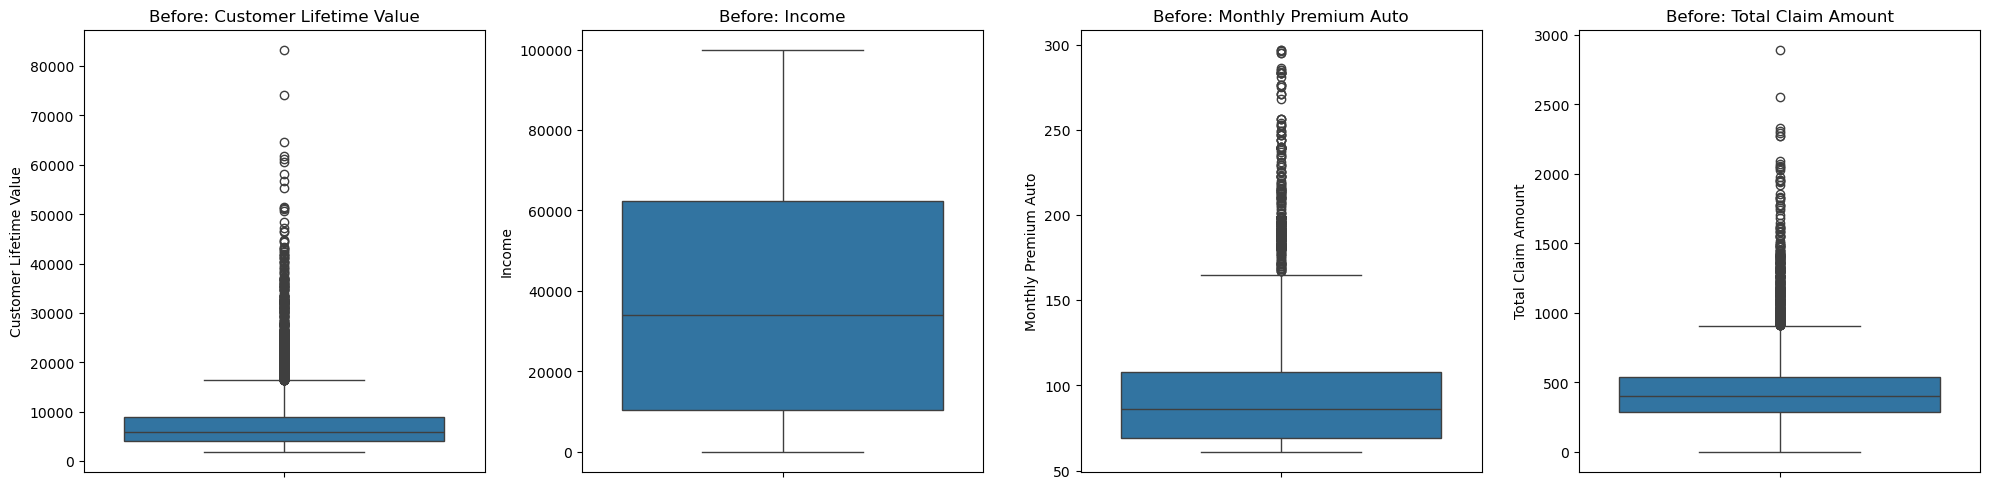

In [15]:
print("Outliers BEFORE handling:")
plot_outliers(X_train, numerical_cols, "Before")


In [16]:
def handle_outliers_logical(data):
    df_temp = data.copy()
    for col in numerical_cols:
        Q1 = df_temp[col].quantile(0.25)
        Q3 = df_temp[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # The "Capping" logic: Values above upper bound are set to upper bound
        # Values below lower bound are set to lower bound
        df_temp[col] = np.where(df_temp[col] > upper_bound, upper_bound, df_temp[col])
        df_temp[col] = np.where(df_temp[col] < lower_bound, lower_bound, df_temp[col])
    return df_temp

Outliers AFTER handling (Capping):


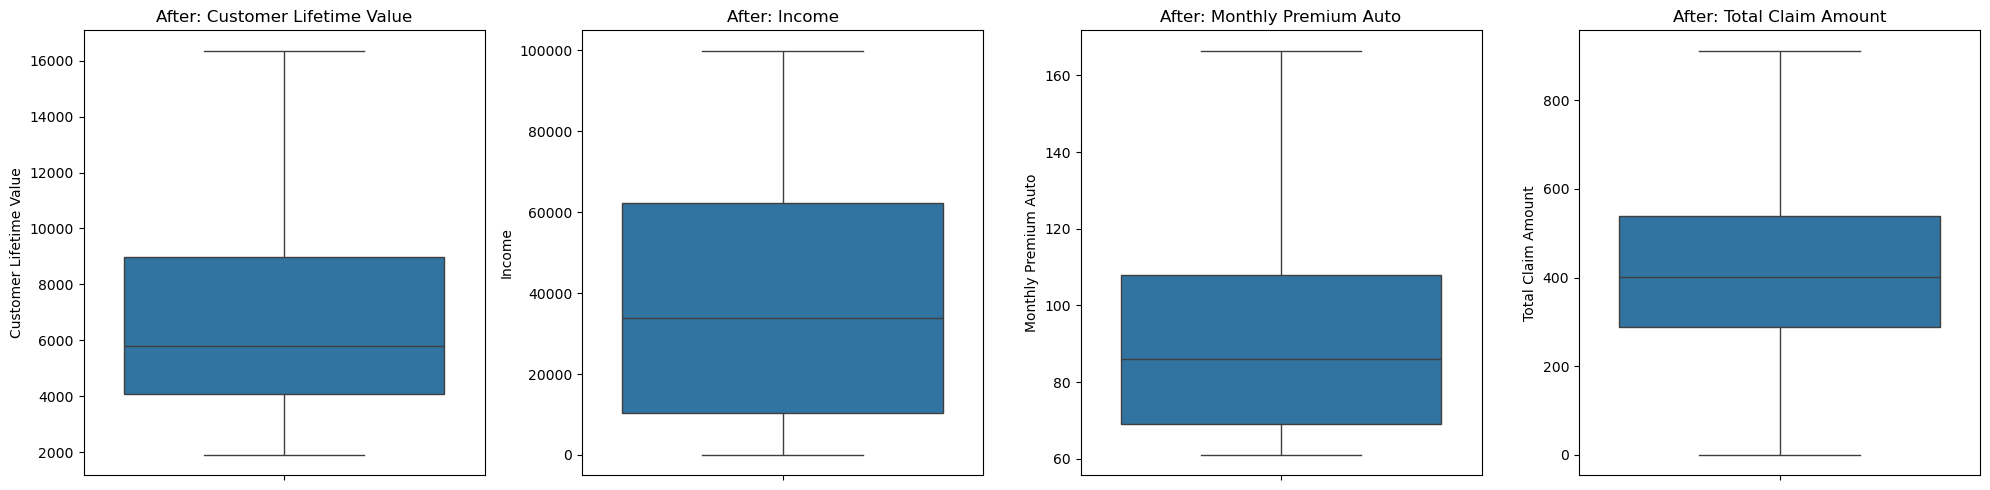

In [17]:

X_train_clean = handle_outliers_logical(X_train)
X_test_clean = handle_outliers_logical(X_test)

print("Outliers AFTER handling (Capping):")
plot_outliers(X_train_clean, numerical_cols, "After")

In [18]:
X_train_numeric = X_train.select_dtypes(include=['number'])

print("==== AFTER CLEANING — TRAIN SET ====")
print("Mean (X_train):")
print(X_train_numeric.mean())

print("\nVariance (X_train):")
print(X_train_numeric.var())

==== AFTER CLEANING — TRAIN SET ====
Mean (X_train):
Customer Lifetime Value           7975.945276
Income                           37730.048647
Monthly Premium Auto                93.450452
Months Since Last Claim             15.100266
Months Since Policy Inception       47.987956
Number of Open Complaints            0.384170
Number of Policies                   2.986235
Total Claim Amount                 434.820548
dtype: float64

Variance (X_train):
Customer Lifetime Value          4.513658e+07
Income                           9.135210e+08
Monthly Premium Auto             1.144230e+03
Months Since Last Claim          1.022679e+02
Months Since Policy Inception    7.758314e+02
Number of Open Complaints        8.514515e-01
Number of Policies               5.756694e+00
Total Claim Amount               8.109944e+04
dtype: float64


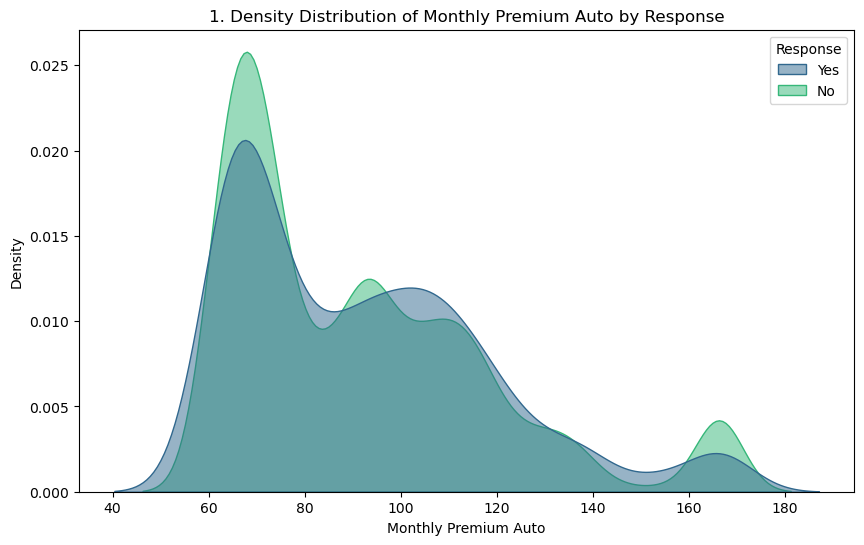

In [19]:
#**1. Density Distribution of Monthly Premium Auto by Response (KDE Plot):**
# it Displays the density of `Monthly Premium Auto` values for responders ('Yes') and non-responders ('No').
# it Identifies if a specific premium range is more likely to result in a 'Yes' response.

viz_df = X_train_clean.copy()
viz_df['Response'] = y_train.values

# 1. Density Plot (KDE) of Monthly Premium Auto by Response
plt.figure(figsize=(10, 6))
sns.kdeplot(data=viz_df, x='Monthly Premium Auto', hue='Response', fill=True, common_norm=False, palette='viridis', alpha=0.5)
plt.title('1. Density Distribution of Monthly Premium Auto by Response')
plt.show()


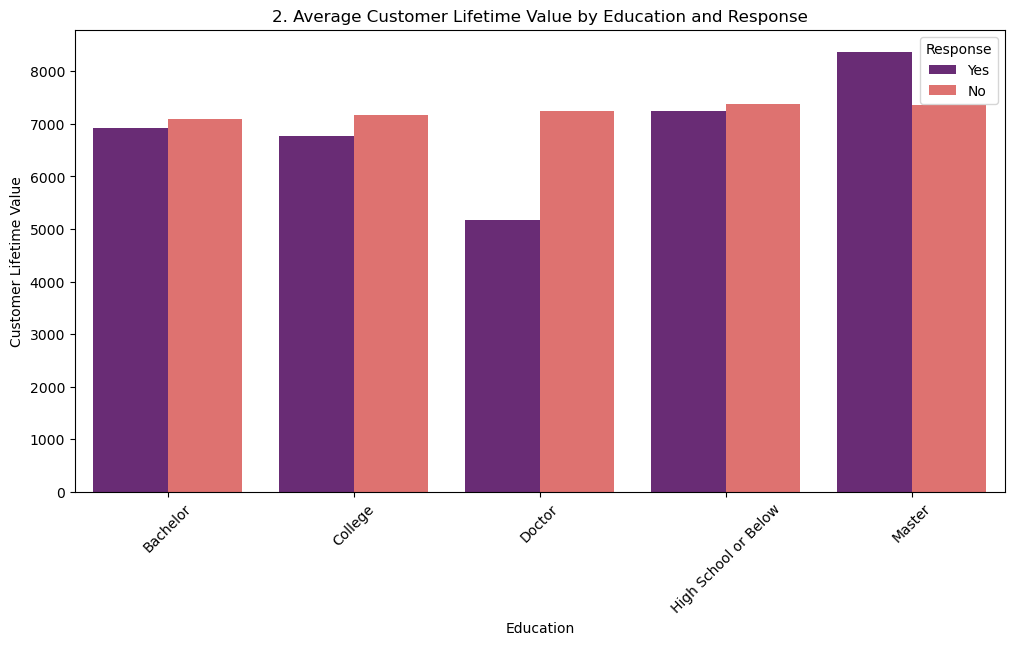

In [20]:
# Average Customer Lifetime Value by Education and Response
plt.figure(figsize=(12, 6))
sns.barplot(data=viz_df, x='Education', y='Customer Lifetime Value', hue='Response', palette='magma', errorbar=None)
plt.title('2. Average Customer Lifetime Value by Education and Response')
plt.xticks(rotation=45)
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_18372\21070294.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=conversion_rates, x='Renew Offer Type', y='Response', palette='viridis')


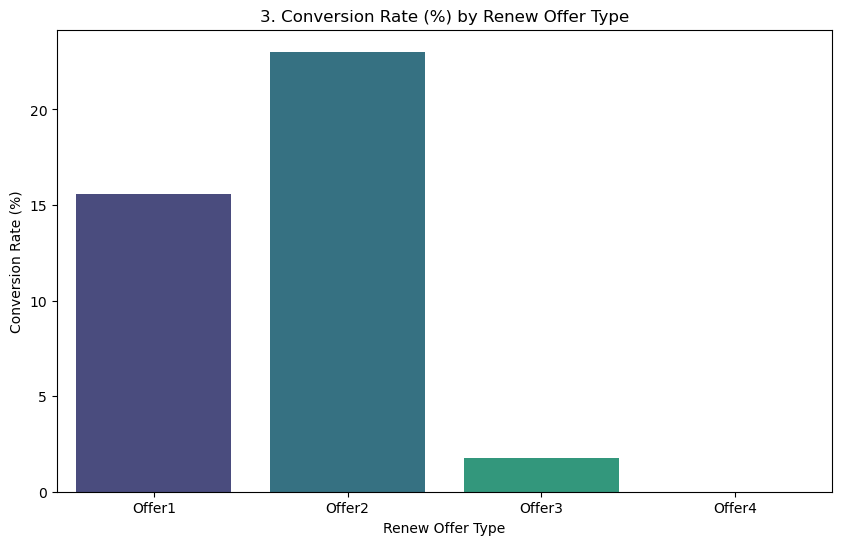

In [21]:

# Conversion Rate (%) by Renew Offer Type
conversion_rates = viz_df.groupby('Renew Offer Type')['Response'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=conversion_rates, x='Renew Offer Type', y='Response', palette='viridis')
plt.title('3. Conversion Rate (%) by Renew Offer Type')
plt.ylabel('Conversion Rate (%)')
plt.show()


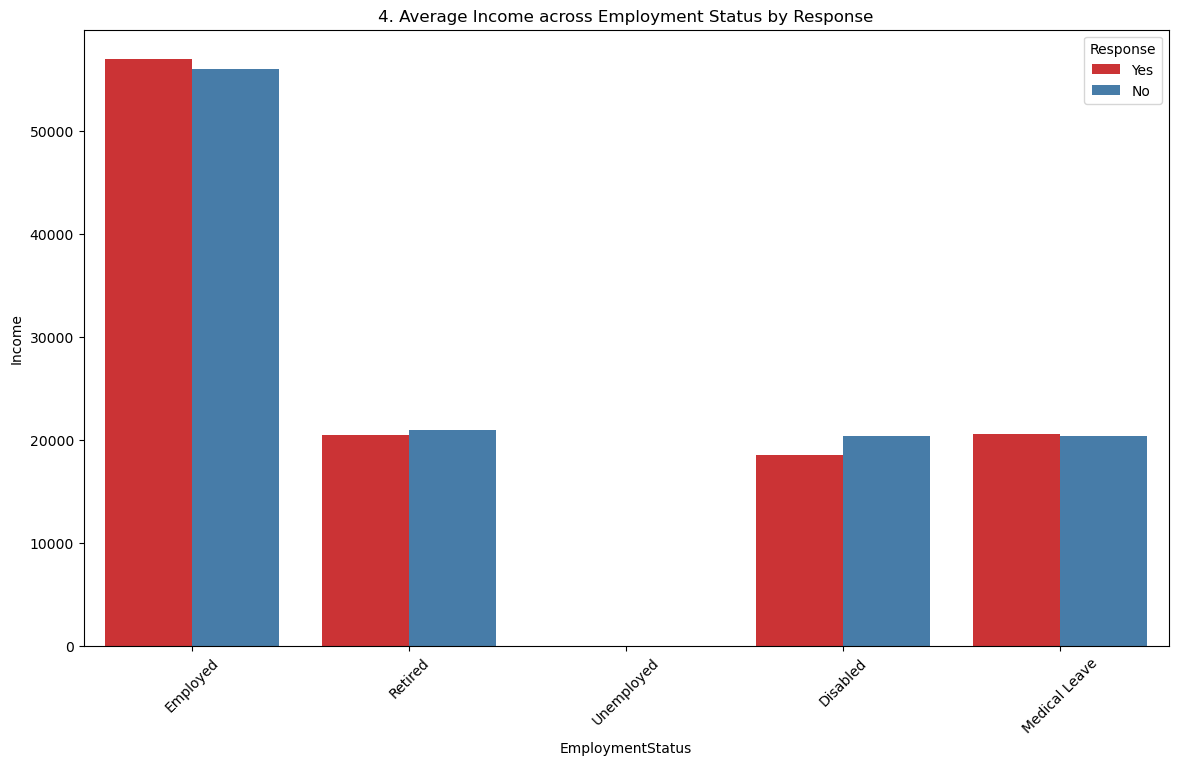

In [22]:
# 4. Average Income by Employment Status and Response (Grouped Bar Chart)
plt.figure(figsize=(14, 8))
sns.barplot(data=viz_df, x='EmploymentStatus', y='Income', hue='Response', palette='Set1', errorbar=None)
plt.title('4. Average Income across Employment Status by Response')
plt.xticks(rotation=45)
plt.show()


C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


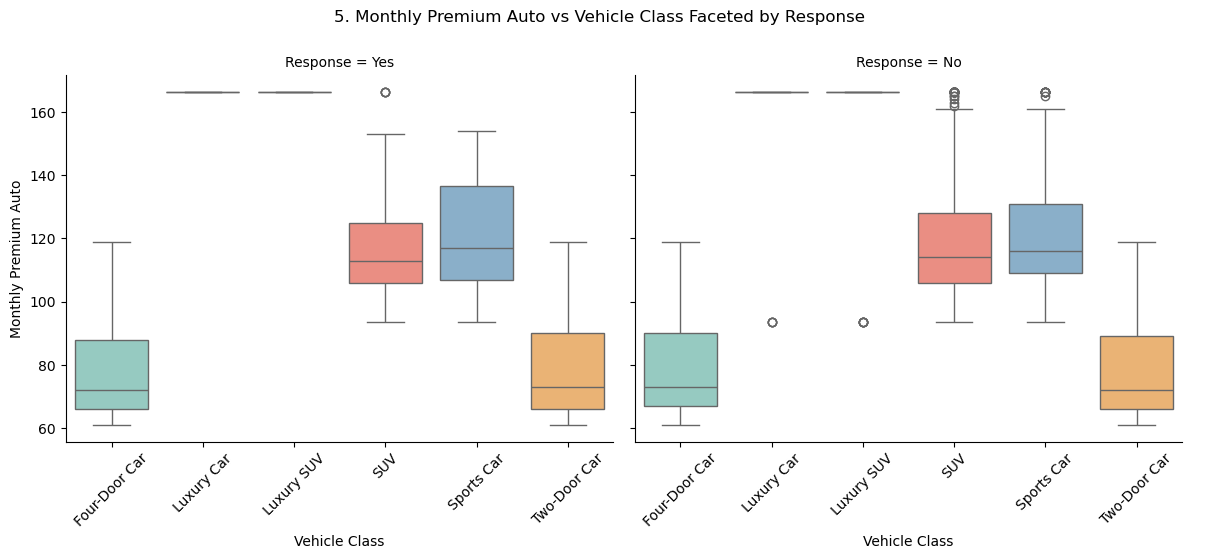

In [23]:
# 5. Faceted Interaction: Monthly Premium Auto vs Vehicle Class Faceted by Response
g = sns.FacetGrid(viz_df, col="Response", height=5, aspect=1.2)
g.map(sns.boxplot, "Vehicle Class", "Monthly Premium Auto", order=sorted(viz_df['Vehicle Class'].unique()), palette='Set3')
g.add_legend()
g.set_xticklabels(rotation=45)
plt.subplots_adjust(top=0.85)
g.fig.suptitle('5. Monthly Premium Auto vs Vehicle Class Faceted by Response')
plt.show()

In [24]:
# --- Categorical Encoding ---

# Drop uninformative columns
drop_cols = ['Customer', 'Effective To Date']
train_final = X_train_clean.drop(drop_cols, axis=1)
test_final = X_test_clean.drop(drop_cols, axis=1)

# Encode categorical features
le = LabelEncoder()
categorical_cols = train_final.select_dtypes(include=['object']).columns

for col in categorical_cols:
    train_final[col] = le.fit_transform(train_final[col])
    
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    test_final[col] = test_final[col].map(mapping).fillna(-1).astype(int)

# Scale numerical features for clustering
scaler = StandardScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train_final), columns=train_final.columns)
test_scaled = pd.DataFrame(scaler.transform(test_final), columns=test_final.columns)

In [25]:
train_final

,State,Customer Lifetime Value,Coverage,Education,EmploymentStatus,Gender,Income,Location Code,Marital Status,Monthly Premium Auto,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
434,4,5015.009472,1,0,1,0,48567.0,1,2,130.0,...,15.0,0.0,1.0,0,1,1,0,624.000000,3,1
4641,3,5149.301306,1,0,1,0,26877.0,1,1,131.0,...,2.0,0.0,1.0,1,4,3,0,628.800000,3,2
4952,1,4904.894731,1,1,3,0,12902.0,1,0,139.0,...,51.0,0.0,1.0,1,5,0,0,434.820548,4,1
1489,0,8510.525936,1,1,4,0,0.0,1,2,121.0,...,94.0,0.0,8.0,1,4,1,1,871.200000,4,1
812,0,3278.531880,1,2,1,1,70247.0,0,2,83.0,...,19.0,0.0,1.0,1,4,3,2,141.799422,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,1,7334.328083,0,1,1,0,87957.0,1,0,61.0,...,63.0,0.0,2.0,1,5,2,0,308.321335,0,2
5191,1,5498.940679,0,1,2,1,22520.0,1,1,73.0,...,64.0,0.0,3.0,1,5,0,1,350.400000,0,1
5390,1,8992.779137,1,3,4,0,0.0,1,2,129.0,...,4.0,0.0,7.0,1,3,0,2,911.556384,3,1
860,0,14635.451580,1,0,4,0,0.0,1,0,139.0,...,56.0,0.0,2.0,1,5,0,2,667.200000,3,1


In [26]:
#label encoding for y_train and y_test
le_y = LabelEncoder()
y_train_enc = le_y.fit_transform(y_train)
y_test_enc = le_y.transform(y_test)

C:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\DELL\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(

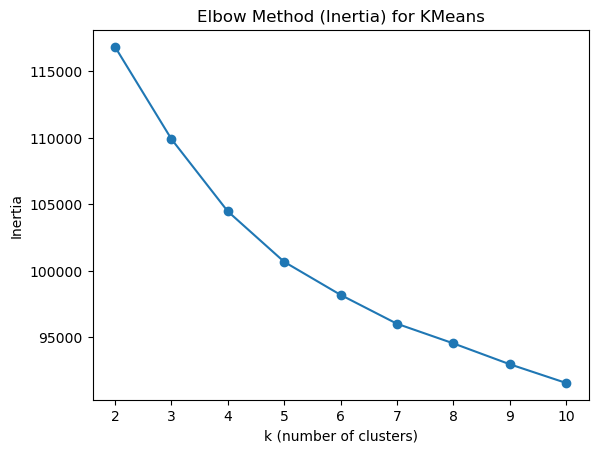

Selected number of clusters (k): 4


In [27]:
# KMeans: choose number of clusters using Elbow Method
# (uses scaled, label-encoded features)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k_values = range(2, 11)
inertias = []

for k in k_values:
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    km.fit(train_scaled)
    inertias.append(km.inertia_)

# Plot Elbow Curve
plt.figure()
plt.plot(list(k_values), inertias, marker="o")
plt.title("Elbow Method (Inertia) for KMeans")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.show()

# selected k based on the elbow point
best_k = 4  
print("Selected number of clusters (k):", best_k)


In [28]:
# KMeans clustering
from sklearn.cluster import KMeans
import numpy as np


X_scaled = np.asarray(train_scaled)

kmeans = KMeans(n_clusters=best_k, init="k-means++", n_init=10, random_state=42)
kmeans.fit(X_scaled)

y_kmeans = kmeans.predict(X_scaled)

# Save cluster labels into my encoded dataframe
train_final["Cluster"] = y_kmeans

print("KMeans fitted. Unique clusters:", np.unique(y_kmeans))


KMeans fitted. Unique clusters: [0 1 2 3]


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


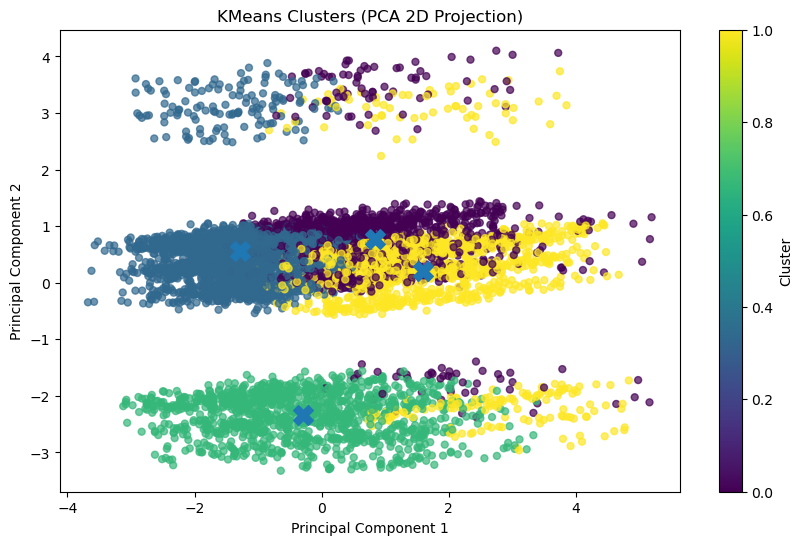

In [29]:
# Visualize KMeans clusters using PCA
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt 

pca = PCA(n_components=2, random_state=42) 
train_pca = pca.fit_transform(train_scaled) 
plt.figure(figsize=(10, 6))
plt.scatter(train_pca[:, 0], train_pca[:, 1], c=train_final["Cluster"], s=25, alpha=0.7) 
centers_pca = pca.transform(kmeans.cluster_centers_) 
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], s=200, marker="X") 
plt.title("KMeans Clusters (PCA 2D Projection)") 
plt.xlabel("Principal Component 1") 
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()

In [31]:

# Predict clusters for the test set using the trained kmeans
test_final["Cluster"] = kmeans.predict(np.asarray(test_scaled))

print("Cluster column added to test_final.")
print("Train clusters:", np.unique(train_final["Cluster"]))
print("Test clusters:", np.unique(test_final["Cluster"]))


Cluster column added to test_final.
Train clusters: [0 1 2 3]
Test clusters: [0 1 2 3]


In [32]:
## Installed imblearn to use oversampling techniques
!pip install -U imbalanced-learn

Class distribution BEFORE SMOTE:
Response
No     5494
Yes     899
Name: count, dtype: int64

X_train shape: (6393, 23)
y_train shape: (6393,)


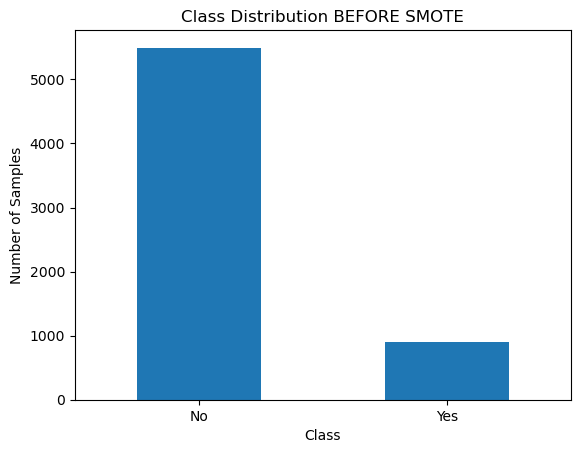

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# Count classes before SMOTE
before_counts = pd.Series(y_train).value_counts()
print("Class distribution BEFORE SMOTE:")
print(pd.Series(y_train).value_counts())
print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

plt.figure()
before_counts.plot(kind="bar")
plt.title("Class Distribution BEFORE SMOTE")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()


Class distribution AFTER SMOTE:
1    5494
0    5494
Name: count, dtype: int64

X_train_smote shape: (10988, 22)
y_train_smote shape: (10988,)


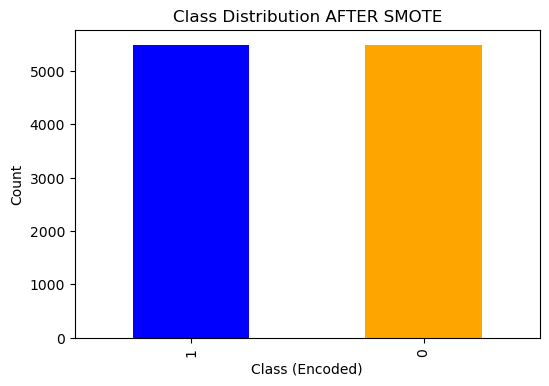

In [34]:
# Apply SMOTE to handle imbalanced dataset
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(train_final, y_train_enc)

print("Class distribution AFTER SMOTE:")
print(pd.Series(y_train_smote).value_counts())
print(f"\nX_train_smote shape: {X_train_smote.shape}")
print(f"y_train_smote shape: {y_train_smote.shape}")


plt.figure(figsize=(6, 4))
pd.Series(y_train_smote).value_counts().plot(kind='bar', color=['blue', 'orange'])
plt.title('Class Distribution AFTER SMOTE')
plt.xlabel('Class (Encoded)')
plt.ylabel('Count')
plt.show()

In [64]:
# Learning Curve 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve_light(model, X, y, title):
    train_sizes, train_scores, valid_scores = learning_curve(
        model,
        X, y,
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8)
    )

    train_mean = train_scores.mean(axis=1)
    valid_mean = valid_scores.mean(axis=1)

    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111)

    ax.scatter(train_sizes, train_mean)
    ax.scatter(train_sizes, valid_mean)

    ax.plot(train_sizes, train_mean, label="Training Accuracy")
    ax.plot(train_sizes, valid_mean, label="Validation Accuracy")

    ax.set_xlabel("Data Range")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()


In [46]:

# Feature Selection using LASSO (L1 Regularization)

# In this cell, LASSO regularization is applied as a feature selection technique
# for Logistic Regression. LASSO works by shrinking less important feature
# coefficients to zero, effectively removing them from the model.

# This approach is suitable for Logistic Regression because it:
# - Reduces model complexity
# - Improves interpretability
# - Helps prevent overfitting

# Feature selection is performed only on the training data to avoid data leakage,
# and the same selected features are then applied to the test set.



import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel


X_test_aligned = test_final.reindex(columns=X_train_smote.columns).fillna(0)


lasso_selector_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,
    max_iter=3000,
    random_state=42
)

lasso_selector = SelectFromModel(lasso_selector_model)
lasso_selector.fit(X_train_smote, y_train_smote)


X_train_lasso = lasso_selector.transform(X_train_smote)
X_test_lasso  = lasso_selector.transform(X_test_aligned)


selected_mask = lasso_selector.get_support()
selected_feature_names = X_train_smote.columns[selected_mask]

print("Number of selected features (LASSO):", len(selected_feature_names))
print("\nSelected feature names:")
for f in selected_feature_names:
    print("-", f)


Number of selected features (LASSO): 20

Selected feature names:
- State
- Customer Lifetime Value
- Coverage
- Education
- EmploymentStatus
- Gender
- Location Code
- Marital Status
- Monthly Premium Auto
- Months Since Last Claim
- Months Since Policy Inception
- Number of Policies
- Policy Type
- Policy
- Renew Offer Type
- Sales Channel
- Total Claim Amount
- Vehicle Class
- Vehicle Size
- Cluster


In [47]:
# Hyperparameter Tuning for Logistic Regression 

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=3000, random_state=42)

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],  
    "solver": ["lbfgs", "liblinear"]
}

grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring="f1",     
    cv=5,
    n_jobs=-1
)

grid_lr.fit(X_train_lasso, y_train_smote)

print("Best Params:", grid_lr.best_params_)
print("Best CV F1 Score:", grid_lr.best_score_)


Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1 Score: 0.6913107607450375


In [48]:
# Train Logistic Regression using best params from GridSearchCV on LASSO-Selected Features

# After selecting the most relevant features using LASSO, a Logistic Regression
# model is trained using the reduced feature space.

# The model is trained on the SMOTE-balanced training set to address class
# imbalance in the target variable.


best_lr_model = grid_lr.best_estimator_
best_lr_model.fit(X_train_lasso, y_train_smote)

print("Logistic Regression trained using tuned hyperparameters.")
print("Final Model:", best_lr_model)


Logistic Regression trained using tuned hyperparameters.
Final Model: LogisticRegression(C=1, max_iter=3000, random_state=42, solver='liblinear')


In [42]:
from sklearn.linear_model import LogisticRegression

lr_lasso_model = LogisticRegression(max_iter=3000, random_state=42)
lr_lasso_model.fit(X_train_lasso, y_train_smote)

print("Logistic Regression trained on LASSO-selected features.")


Logistic Regression trained on LASSO-selected features.


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression (TUNED): TRAIN ===
Accuracy: 0.6945759009828905
AUC: 0.77552279622248
Confusion Matrix:
 [[3786 1708]
 [1648 3846]]

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.69      0.69      5494
           1       0.69      0.70      0.70      5494

    accuracy                           0.69     10988
   macro avg       0.69      0.69      0.69     10988
weighted avg       0.69      0.69      0.69     10988



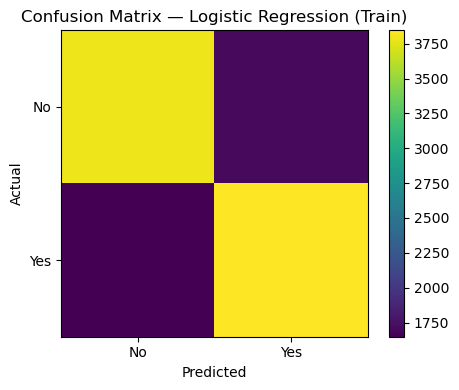


=== Logistic Regression (TUNED): TEST ===
Accuracy: 0.6519518423932871
AUC: 0.6465503864590455
Confusion Matrix:
 [[1606  726]
 [ 228  181]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.69      0.77      2332
           1       0.20      0.44      0.28       409

    accuracy                           0.65      2741
   macro avg       0.54      0.57      0.52      2741
weighted avg       0.77      0.65      0.70      2741



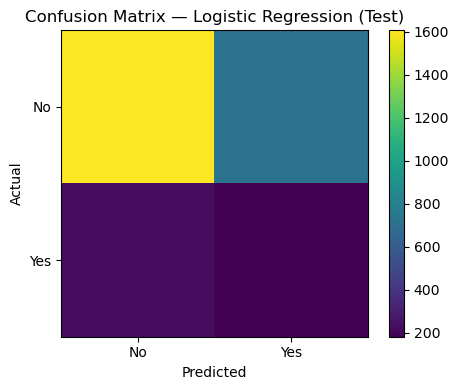

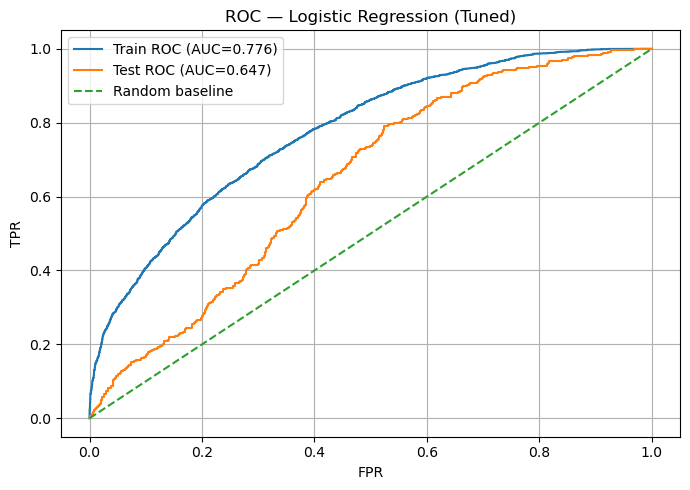

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
4 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1276, in fit
    self.coef_, self

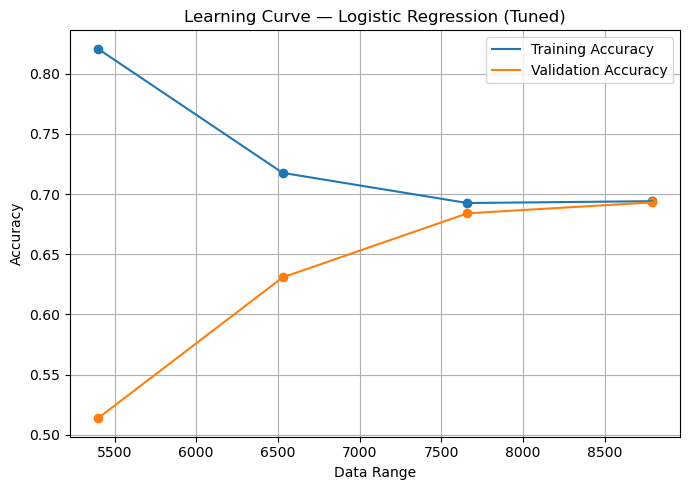

In [70]:
# Model Evaluation for LR
# I evaluates the model using multiple performance metrics:
# - Accuracy
# - F1-score
# - Precision and Recall
# - ROC curve and AUC
# Using multiple metrics is necessary because the dataset is imbalanced.
# Accuracy alone can be misleading, as a model may achieve high accuracy by
# predicting the majority class while failing to detect the minority class.
# F1-score and AUC provide a more reliable assessment of model performance under class imbalance.




from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

# Predictions (Train/Test)
y_train_pred_lr = best_lr_model.predict(X_train_lasso)
y_test_pred_lr  = best_lr_model.predict(X_test_lasso)

# Probabilities for ROC/AUC
y_train_proba_lr = best_lr_model.predict_proba(X_train_lasso)[:, 1]
y_test_proba_lr  = best_lr_model.predict_proba(X_test_lasso)[:, 1]


# TRAIN Results
print("=== Logistic Regression (TUNED): TRAIN ===")
print("Accuracy:", accuracy_score(y_train_smote, y_train_pred_lr))
print("AUC:", roc_auc_score(y_train_smote, y_train_proba_lr))
print("Confusion Matrix:\n", confusion_matrix(y_train_smote, y_train_pred_lr))
print("\nClassification Report:\n", classification_report(y_train_smote, y_train_pred_lr))

# Visual Confusion Matrix (TRAIN)
cm_tr = confusion_matrix(y_train_smote, y_train_pred_lr)
plt.figure(figsize=(5, 4))
plt.imshow(cm_tr)
plt.title("Confusion Matrix — Logistic Regression (Train)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], le_y.classes_)
plt.yticks([0, 1], le_y.classes_)
plt.tight_layout()
plt.show()


# TEST Results
print("\n=== Logistic Regression (TUNED): TEST ===")
print("Accuracy:", accuracy_score(y_test_enc, y_test_pred_lr))
print("AUC:", roc_auc_score(y_test_enc, y_test_proba_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test_enc, y_test_pred_lr))
print("\nClassification Report:\n", classification_report(y_test_enc, y_test_pred_lr))

# Visual Confusion Matrix (TEST)
cm_te = confusion_matrix(y_test_enc, y_test_pred_lr)
plt.figure(figsize=(5, 4))
plt.imshow(cm_te)
plt.title("Confusion Matrix — Logistic Regression (Test)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], le_y.classes_)
plt.yticks([0, 1], le_y.classes_)
plt.tight_layout()
plt.show()


# ROC Curves (Train/Test)
fpr_tr, tpr_tr, _ = roc_curve(y_train_smote, y_train_proba_lr)
fpr_te, tpr_te, _ = roc_curve(y_test_enc,  y_test_proba_lr)

plt.figure(figsize=(7,5))
plt.plot(fpr_tr, tpr_tr, label=f"Train ROC (AUC={roc_auc_score(y_train_smote, y_train_proba_lr):.3f})")
plt.plot(fpr_te, tpr_te, label=f"Test ROC (AUC={roc_auc_score(y_test_enc, y_test_proba_lr):.3f})")
plt.plot([0, 1], [0, 1], "--", label="Random baseline")
plt.title("ROC — Logistic Regression (Tuned)")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Learning Curve for Logistic Regression (Tuned)
plot_learning_curve_light(
    best_lr_model,
    X_train_lasso,
    y_train_smote,
    "Learning Curve — Logistic Regression (Tuned)"
)



In [50]:
# Feature Selection (KBest) for Random Forest 

# In this cell, K-Best feature selection is applied using a statistical scoring
# method to select the most informative features.

# This method is appropriate for Random Forest because:
# - Tree-based models can handle non-linear relationships
# - K-Best helps reduce dimensionality without harming performance
# The selected features are used consistently for both training and testing.


import numpy as np
import pandas as pd
from sklearn.feature_selection import SelectKBest, mutual_info_classif


X_test_aligned = test_final.reindex(columns=X_train_smote.columns).fillna(0)


k_best = 15  

kbest_selector = SelectKBest(score_func=mutual_info_classif, k=k_best)
kbest_selector.fit(X_train_smote, y_train_smote)

X_train_kbest = kbest_selector.transform(X_train_smote)
X_test_kbest  = kbest_selector.transform(X_test_aligned)


selected_mask = kbest_selector.get_support()
selected_feature_names_rf = X_train_smote.columns[selected_mask]

print("Number of selected features (KBest):", len(selected_feature_names_rf))
print("\nSelected feature names:")
for f in selected_feature_names_rf:
    print("-", f)


Number of selected features (KBest): 15

Selected feature names:
- State
- Customer Lifetime Value
- EmploymentStatus
- Income
- Location Code
- Marital Status
- Monthly Premium Auto
- Months Since Last Claim
- Months Since Policy Inception
- Number of Policies
- Policy Type
- Policy
- Renew Offer Type
- Sales Channel
- Total Claim Amount


In [51]:
# Hyperparameter Tuning for Random Forest (after KBest selection)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1",   
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train_kbest, y_train_smote)

print("Best Params:", grid_rf.best_params_)
print("Best CV F1 Score:", grid_rf.best_score_)


C:\Users\DELL\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Params: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1 Score: 0.9749153738990394


In [52]:
# Train Random Forest using best params from GridSearchCV

best_rf_model = grid_rf.best_estimator_
best_rf_model.fit(X_train_kbest, y_train_smote)

print("Random Forest trained using tuned hyperparameters.")
print("Final Model:", best_rf_model)


Random Forest trained using tuned hyperparameters.
Final Model: RandomForestClassifier(bootstrap=False, n_estimators=200, random_state=42)


=== Random Forest (TUNED): TRAIN ===
Accuracy: 1.0
AUC: 1.0
Confusion Matrix:
 [[5494    0]
 [   0 5494]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5494
           1       1.00      1.00      1.00      5494

    accuracy                           1.00     10988
   macro avg       1.00      1.00      1.00     10988
weighted avg       1.00      1.00      1.00     10988



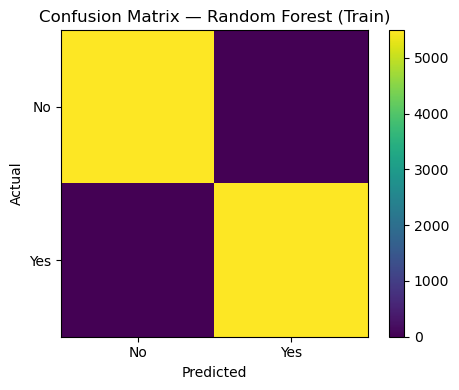


=== Random Forest (TUNED): TEST ===
Accuracy: 0.9543962057643196
AUC: 0.9816332350585246
Confusion Matrix:
 [[2289   43]
 [  82  327]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97      2332
           1       0.88      0.80      0.84       409

    accuracy                           0.95      2741
   macro avg       0.92      0.89      0.91      2741
weighted avg       0.95      0.95      0.95      2741



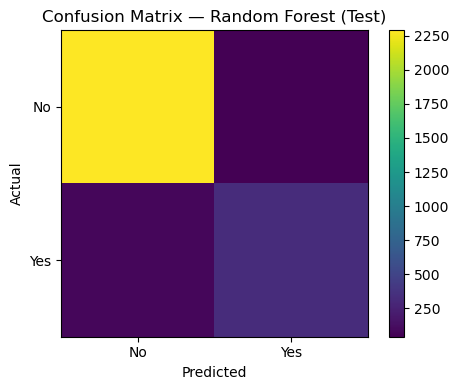

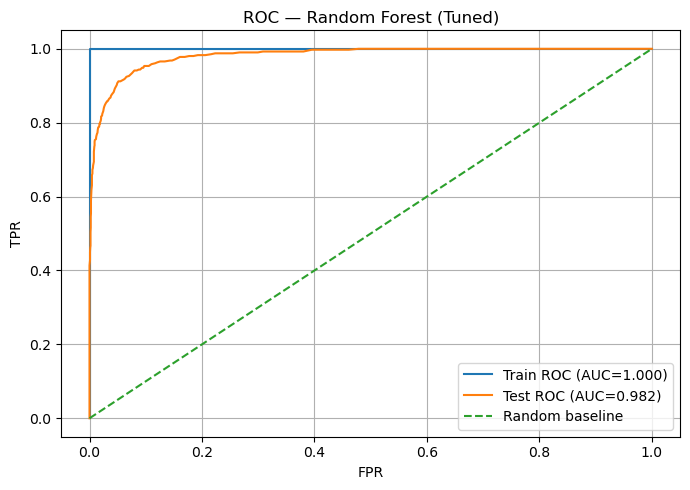

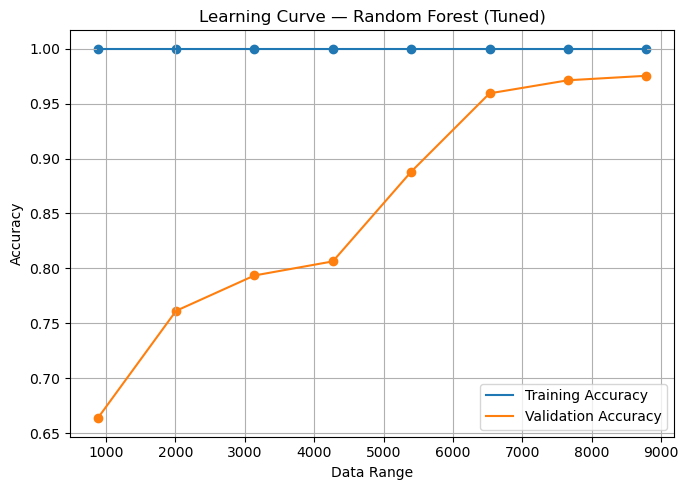

In [67]:

# Model Evaluation for RF
# This cell evaluates the model using multiple performance metrics:
# - Accuracy
# - F1-score
# - Precision and Recall
# - ROC curve and AUC


from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt


# Predictions (Train/Test)
y_train_pred_rf = best_rf_model.predict(X_train_kbest)
y_test_pred_rf  = best_rf_model.predict(X_test_kbest)

# Probabilities for ROC/AUC
y_train_proba_rf = best_rf_model.predict_proba(X_train_kbest)[:, 1]
y_test_proba_rf  = best_rf_model.predict_proba(X_test_kbest)[:, 1]


# TRAIN Results
print("=== Random Forest (TUNED): TRAIN ===")
print("Accuracy:", accuracy_score(y_train_smote, y_train_pred_rf))
print("AUC:", roc_auc_score(y_train_smote, y_train_proba_rf))
print("Confusion Matrix:\n", confusion_matrix(y_train_smote, y_train_pred_rf))
print("\nClassification Report:\n", classification_report(y_train_smote, y_train_pred_rf))

# Visual Confusion Matrix (TRAIN)
cm_tr = confusion_matrix(y_train_smote, y_train_pred_rf)
plt.figure(figsize=(5, 4))
plt.imshow(cm_tr)
plt.title("Confusion Matrix — Random Forest (Train)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], le_y.classes_)
plt.yticks([0, 1], le_y.classes_)
plt.tight_layout()
plt.show()

# TEST Results
print("\n=== Random Forest (TUNED): TEST ===")
print("Accuracy:", accuracy_score(y_test_enc, y_test_pred_rf))
print("AUC:", roc_auc_score(y_test_enc, y_test_proba_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test_enc, y_test_pred_rf))
print("\nClassification Report:\n", classification_report(y_test_enc, y_test_pred_rf))

# Visual Confusion Matrix (TEST)
cm_te = confusion_matrix(y_test_enc, y_test_pred_rf)
plt.figure(figsize=(5, 4))
plt.imshow(cm_te)
plt.title("Confusion Matrix — Random Forest (Test)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], le_y.classes_)
plt.yticks([0, 1], le_y.classes_)
plt.tight_layout()
plt.show()


# ROC Curves (Train/Test)
fpr_tr, tpr_tr, _ = roc_curve(y_train_smote, y_train_proba_rf)
fpr_te, tpr_te, _ = roc_curve(y_test_enc,  y_test_proba_rf)

plt.figure(figsize=(7,5))
plt.plot(fpr_tr, tpr_tr, label=f"Train ROC (AUC={roc_auc_score(y_train_smote, y_train_proba_rf):.3f})")
plt.plot(fpr_te, tpr_te, label=f"Test ROC (AUC={roc_auc_score(y_test_enc, y_test_proba_rf):.3f})")
plt.plot([0, 1], [0, 1], "--", label="Random baseline")
plt.title("ROC — Random Forest (Tuned)")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

# Learning Curve for Random Forest (Tuned)
plot_learning_curve_light(
    best_rf_model,
    X_train_kbest,
    y_train_smote,
    "Learning Curve — Random Forest (Tuned)"
)


In [57]:

# KNN Model Training with Feature Selection
# K-Nearest Neighbors is sensitive to irrelevant features and feature scaling. Therefore, feature selection is applied before training the model.

# Reducing dimensionality improves:
# - Distance calculations
# - Model stability
# - Prediction accuracy


# Feature Selection for KNN using SelectKBest (Mutual Information)
from sklearn.feature_selection import SelectKBest, mutual_info_classif


X_test_aligned = test_final.reindex(columns=X_train_smote.columns).fillna(0)


k_best_knn = 15  # adjust (10, 15, 20...)

kbest_knn_selector = SelectKBest(score_func=mutual_info_classif, k=k_best_knn)
kbest_knn_selector.fit(X_train_smote, y_train_smote)


X_train_knn = kbest_knn_selector.transform(X_train_smote)
X_test_knn  = kbest_knn_selector.transform(X_test_aligned)

# Get selected feature names
selected_mask = kbest_knn_selector.get_support()
selected_feature_names_knn = X_train_smote.columns[selected_mask]

print("Number of selected features (KBest for KNN):", len(selected_feature_names_knn))
print("\nSelected feature names:")
for f in selected_feature_names_knn:
    print("-", f)


Number of selected features (KBest for KNN): 15

Selected feature names:
- State
- Customer Lifetime Value
- EmploymentStatus
- Income
- Marital Status
- Monthly Premium Auto
- Months Since Last Claim
- Months Since Policy Inception
- Number of Policies
- Policy
- Renew Offer Type
- Sales Channel
- Total Claim Amount
- Vehicle Size
- Cluster


In [58]:
# Hyperparameter Tuning for KNN (after KBest)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()

param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "weights": ["uniform", "distance"],
    "metric": ["minkowski", "euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_knn.fit(X_train_knn, y_train_smote)

print("Best Params:", grid_knn.best_params_)
print("Best CV F1 Score:", grid_knn.best_score_)


Best Params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best CV F1 Score: 0.9324565952216484


In [59]:
# Train KNN using best params from GridSearchCV

best_knn_model = grid_knn.best_estimator_
best_knn_model.fit(X_train_knn, y_train_smote)

print("KNN trained using tuned hyperparameters.")
print("Final Model:", best_knn_model)


KNN trained using tuned hyperparameters.
Final Model: KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance')


=== KNN (TUNED): TRAIN ===
Accuracy: 1.0
AUC: 1.0
Confusion Matrix:
 [[5494    0]
 [   0 5494]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5494
           1       1.00      1.00      1.00      5494

    accuracy                           1.00     10988
   macro avg       1.00      1.00      1.00     10988
weighted avg       1.00      1.00      1.00     10988



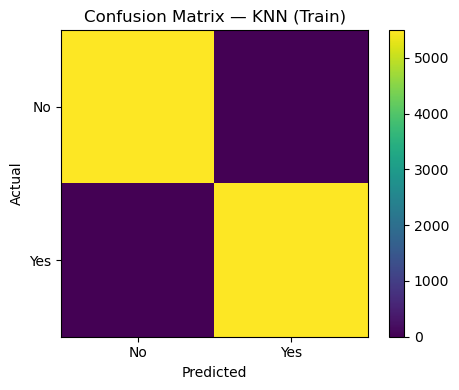


=== KNN (TUNED): TEST ===
Accuracy: 0.8580809923385626
AUC: 0.9051288126921286
Confusion Matrix:
 [[1985  347]
 [  42  367]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.85      0.91      2332
           1       0.51      0.90      0.65       409

    accuracy                           0.86      2741
   macro avg       0.75      0.87      0.78      2741
weighted avg       0.91      0.86      0.87      2741



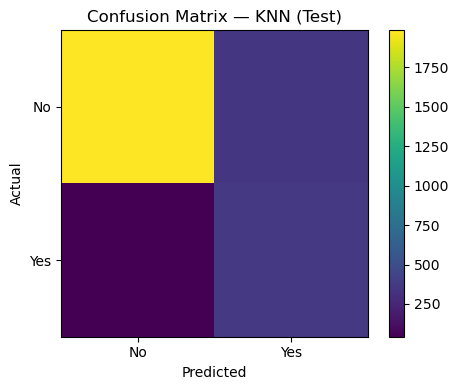

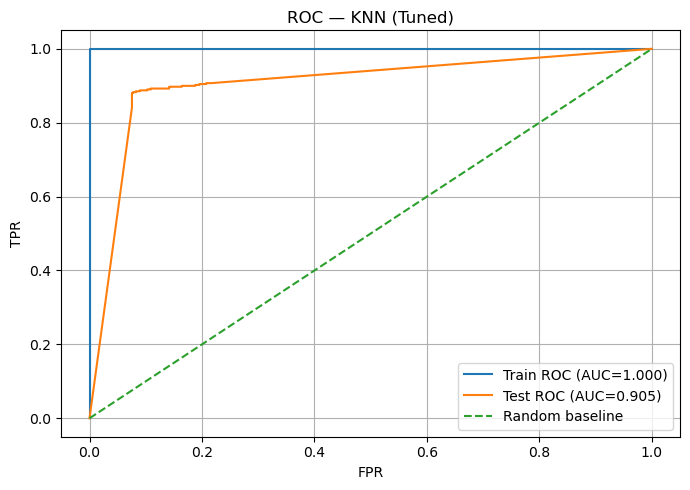

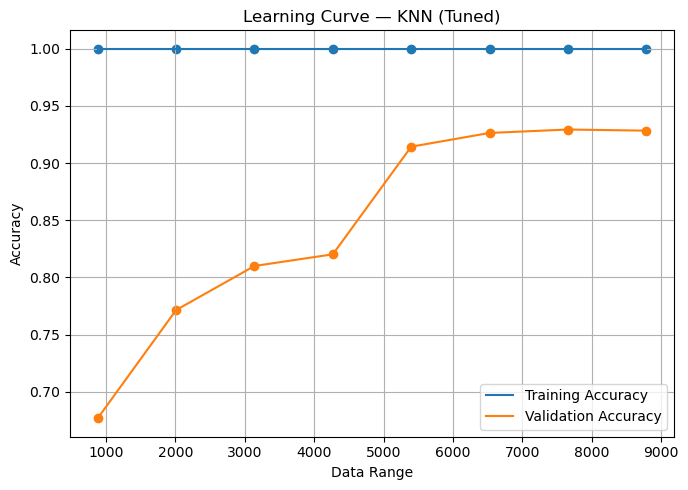

In [68]:
#EValuation for KNN model
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt


# Predictions (Train/Test)
y_train_pred_knn = best_knn_model.predict(X_train_knn)
y_test_pred_knn  = best_knn_model.predict(X_test_knn)

# Probabilities for ROC/AUC
y_train_proba_knn = best_knn_model.predict_proba(X_train_knn)[:, 1]
y_test_proba_knn  = best_knn_model.predict_proba(X_test_knn)[:, 1]


# TRAIN Results
print(" KNN (TUNED): TRAIN ")
print("Accuracy:", accuracy_score(y_train_smote, y_train_pred_knn))
print("AUC:", roc_auc_score(y_train_smote, y_train_proba_knn))
print("Confusion Matrix:\n", confusion_matrix(y_train_smote, y_train_pred_knn))
print("\nClassification Report:\n", classification_report(y_train_smote, y_train_pred_knn))

# Visual Confusion Matrix (TRAIN)
cm_tr = confusion_matrix(y_train_smote, y_train_pred_knn)
plt.figure(figsize=(5, 4))
plt.imshow(cm_tr)
plt.title("Confusion Matrix — KNN (Train)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], le_y.classes_)
plt.yticks([0, 1], le_y.classes_)
plt.tight_layout()
plt.show()


# TEST Results
print("\n=== KNN (TUNED): TEST ===")
print("Accuracy:", accuracy_score(y_test_enc, y_test_pred_knn))
print("AUC:", roc_auc_score(y_test_enc, y_test_proba_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test_enc, y_test_pred_knn))
print("\nClassification Report:\n", classification_report(y_test_enc, y_test_pred_knn))

# Visual Confusion Matrix (TEST)
cm_te = confusion_matrix(y_test_enc, y_test_pred_knn)
plt.figure(figsize=(5, 4))
plt.imshow(cm_te)
plt.title("Confusion Matrix — KNN (Test)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], le_y.classes_)
plt.yticks([0, 1], le_y.classes_)
plt.tight_layout()
plt.show()


# ROC Curves (Train/Test)
fpr_tr, tpr_tr, _ = roc_curve(y_train_smote, y_train_proba_knn)
fpr_te, tpr_te, _ = roc_curve(y_test_enc,  y_test_proba_knn)

plt.figure(figsize=(7,5))
plt.plot(fpr_tr, tpr_tr, label=f"Train ROC (AUC={roc_auc_score(y_train_smote, y_train_proba_knn):.3f})")
plt.plot(fpr_te, tpr_te, label=f"Test ROC (AUC={roc_auc_score(y_test_enc, y_test_proba_knn):.3f})")
plt.plot([0, 1], [0, 1], "--", label="Random baseline")
plt.title("ROC — KNN (Tuned)")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

# Learning Curve for KNN (Tuned)
plot_learning_curve_light(
    best_knn_model,
    X_train_knn,
    y_train_smote,
    "Learning Curve — KNN (Tuned)"
)


In [69]:

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

results = []

models_preds = {
    "Logistic Regression (LASSO + Tuned)": y_pred_lr,
    "Random Forest (KBest + Tuned)": y_pred_rf,
    "KNN (PCA + Tuned)": y_pred_knn
}

for model_name, y_pred in models_preds.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_enc, y_pred),
        "F1": f1_score(y_test_enc, y_pred),
        "Precision": precision_score(y_test_enc, y_pred),
        "Recall": recall_score(y_test_enc, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)

print("Model Comparison (Sorted by F1):")
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_f1 = results_df.iloc[0]["F1"]

print(f"\nBest Model by F1 Score: {best_model_name} (F1 = {best_f1:.4f})")


Model Comparison (Sorted by F1):


,Model,Accuracy,F1,Precision,Recall
1,Random Forest (KBest + Tuned),0.954396,0.839538,0.883784,0.799511
2,KNN (PCA + Tuned),0.858081,0.653606,0.514006,0.897311
0,Logistic Regression (LASSO + Tuned),0.651952,0.275076,0.199559,0.442543



Best Model by F1 Score: Random Forest (KBest + Tuned) (F1 = 0.8395)


In [75]:
#Evaluation for ensemble learning

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

def eval_preds(y_true, y_pred, y_proba, title, class_names=None):
    print(f"=== {title} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("AUC:", roc_auc_score(y_true, y_proba))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

    # Visual Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix — {title}")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    if class_names is not None:
        plt.xticks([0,1], class_names)
        plt.yticks([0,1], class_names)
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_true, y_proba):.3f}")
    plt.plot([0,1], [0,1], "--", label="Random baseline")
    plt.title(f"ROC — {title}")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [104]:

# Hard Voting Ensemble
# In this ensemble approach, predictions from Logistic Regression, Random Forest, and KNN are combined using majority voting.

# Each model contributes one vote, and the final prediction is the class that receives the most votes.
# Hard voting treats all models equally and does not consider confidence levels.




pred_lr  = best_lr_model.predict(X_test_lasso)
pred_rf  = best_rf_model.predict(X_test_kbest)
pred_knn = best_knn_model.predict(X_test_knn)


hard_vote_pred = (pred_lr + pred_rf + pred_knn >= 2).astype(int)

print("Hard Voting done. Sample:", hard_vote_pred[:10])


Hard Voting done. Sample: [0 0 1 0 0 0 0 0 0 0]


=== Hard Voting (LR + RF + KNN) ===
Accuracy: 0.9208318132068588
AUC: 0.9753467227518064
Confusion Matrix:
 [[2187  145]
 [  72  337]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.95      2332
           1       0.70      0.82      0.76       409

    accuracy                           0.92      2741
   macro avg       0.83      0.88      0.85      2741
weighted avg       0.93      0.92      0.92      2741



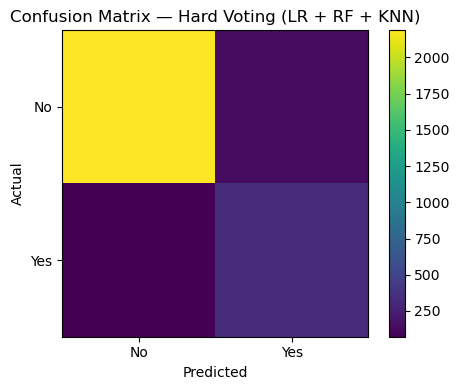

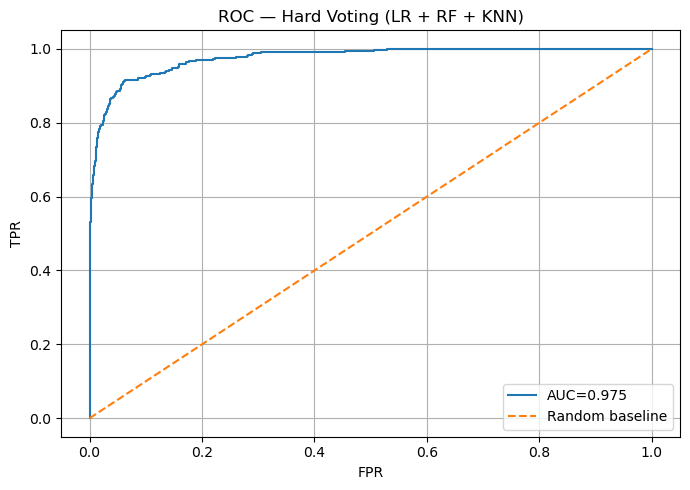

In [105]:

hard_vote_proba = (proba_lr + proba_rf + proba_knn) / 3

eval_preds(
    y_test_enc,
    hard_vote_pred,
    hard_vote_proba,
    "Hard Voting (LR + RF + KNN)",
    class_names=le_y.classes_
)


In [72]:

# Soft Voting Ensemble
# Soft voting combines models by averaging their predicted probabilities rather than their final class labels.

# This method often performs better than hard voting because:
# - It considers model confidence
# - It allows stronger models to influence the final decision more

# A threshold is applied to the averaged probability to determine the final
# prediction.



proba_lr  = best_lr_model.predict_proba(X_test_lasso)[:, 1]
proba_rf  = best_rf_model.predict_proba(X_test_kbest)[:, 1]
proba_knn = best_knn_model.predict_proba(X_test_knn)[:, 1]

avg_proba = (proba_lr + proba_rf + proba_knn) / 3


soft_vote_pred = (avg_proba >= 0.5).astype(int)

print("Soft Voting done. Sample:", soft_vote_pred[:10])


Soft Voting done. Sample: [0 0 1 0 0 0 0 0 0 0]


=== Soft Voting (LR + RF + KNN) ===
Accuracy: 0.9372491791317038
AUC: 0.9753467227518064
Confusion Matrix:
 [[2201  131]
 [  41  368]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96      2332
           1       0.74      0.90      0.81       409

    accuracy                           0.94      2741
   macro avg       0.86      0.92      0.89      2741
weighted avg       0.95      0.94      0.94      2741



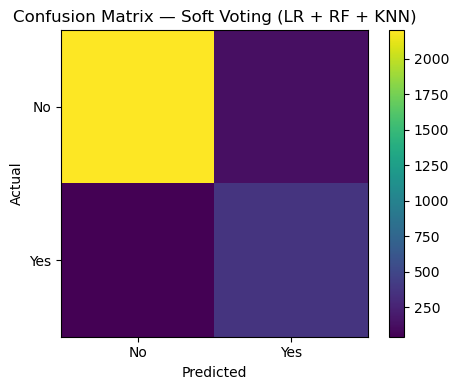

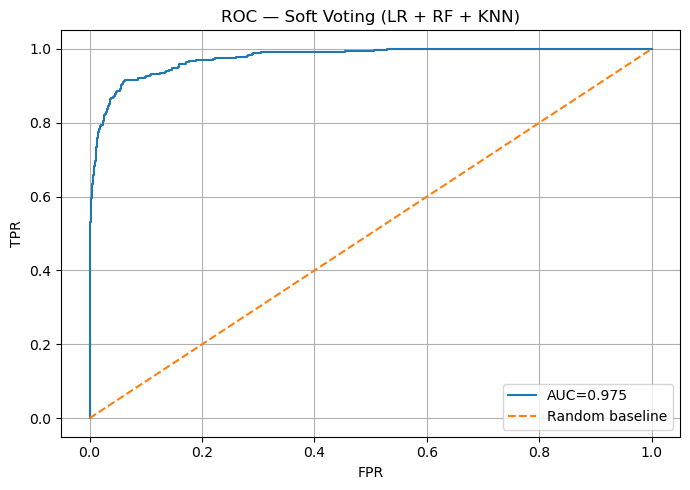

In [77]:
#evaluation for soft voting
eval_preds(
    y_test_enc,
    soft_vote_pred,
    avg_proba,
    "Soft Voting (LR + RF + KNN)",
    class_names=le_y.classes_
)


In [100]:

# Bagging Ensemble using KNN 

# Multiple KNN models are trained on different bootstrap samples of the training data, and their predictions are aggregated.

# This approach reduces variance and stabilizes KNN predictions, which are sensitive to data sampling.

# Logistic Regression was not used for bagging due to its low variance, and Random Forest was excluded because it already implements bagging internally.


from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier


k_opt = best_knn_model.get_params().get("n_neighbors", 5)

bagging_model = BaggingClassifier(
    estimator=KNeighborsClassifier(n_neighbors=k_opt),
    n_estimators=200,
    max_samples=0.8,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

bagging_model.fit(X_train_knn, y_train_smote)

print(f"Bagging(KNN) trained successfully. (Base KNN n_neighbors={k_opt})")


2025/12/20 04:48:12 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '9eb379ef9844430cb8279e3a3feb41b9', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


Bagging(KNN) trained successfully. (Base KNN n_neighbors=3)


=== Bagging (KNN) ===
Accuracy: 0.8445822692448012
AUC: 0.9132904796453718
Confusion Matrix:
 [[1948  384]
 [  42  367]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.84      0.90      2332
           1       0.49      0.90      0.63       409

    accuracy                           0.84      2741
   macro avg       0.73      0.87      0.77      2741
weighted avg       0.91      0.84      0.86      2741



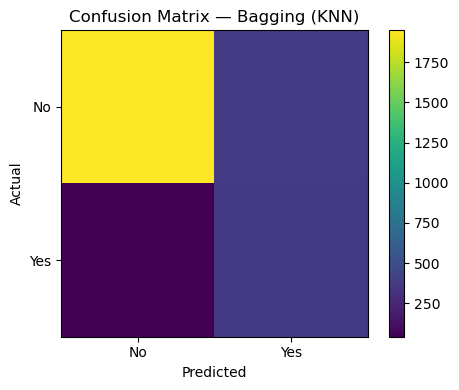

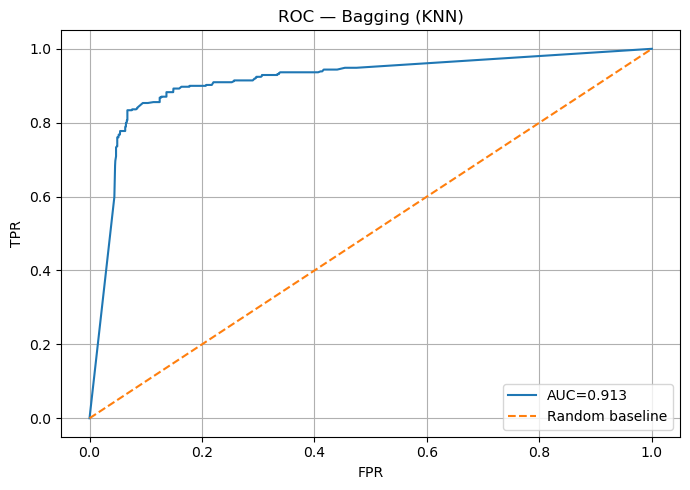

In [102]:

# Evaluation Bagging (KNN)



y_pred_bag = bagging_model.predict(X_test_knn)

y_proba_bag = bagging_model.predict_proba(X_test_knn)[:, 1]

eval_preds(
    y_true=y_test_enc,
    y_pred=y_pred_bag,
    y_proba=y_proba_bag,
    title="Bagging (KNN)",
    class_names=(le_y.classes_ if "le_y" in globals() else None)
)


In [106]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

results = []

# Hard Voting
results.append({
    "Model": "Hard Voting (LR + RF + KNN)",
    "Accuracy": accuracy_score(y_test_enc, hard_vote_pred),
    "F1": f1_score(y_test_enc, hard_vote_pred),
    "Precision": precision_score(y_test_enc, hard_vote_pred),
    "Recall": recall_score(y_test_enc, hard_vote_pred),
    "AUC": roc_auc_score(y_test_enc, hard_vote_proba)
})

# Soft Voting
results.append({
    "Model": "Soft Voting (LR + RF + KNN)",
    "Accuracy": accuracy_score(y_test_enc, soft_vote_pred),
    "F1": f1_score(y_test_enc, soft_vote_pred),
    "Precision": precision_score(y_test_enc, soft_vote_pred),
    "Recall": recall_score(y_test_enc, soft_vote_pred),
    "AUC": roc_auc_score(y_test_enc, avg_proba)
})

# Bagging (KNN) — FIXED
results.append({
    "Model": "Bagging (KNN)",
    "Accuracy": accuracy_score(y_test_enc, y_pred_bag),
    "F1": f1_score(y_test_enc, y_pred_bag),
    "Precision": precision_score(y_test_enc, y_pred_bag),
    "Recall": recall_score(y_test_enc, y_pred_bag),
    "AUC": roc_auc_score(y_test_enc, y_proba_bag)
})

ensemble_results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)

print("Ensemble Models Comparison (sorted by F1):")
display(ensemble_results_df)

best_model = ensemble_results_df.iloc[0]
print(
    f"\nBest Ensemble Model: {best_model['Model']} "
    f"(F1 = {best_model['F1']:.4f}, AUC = {best_model['AUC']:.4f})"
)

# Ensemble Models Comparison
# Three ensemble techniques were evaluated: Hard Voting, Soft Voting, and Bagging.
# Soft Voting achieved the best overall performance in terms of F1-score and AUC,
# indicating that averaging probabilistic outputs from heterogeneous classifiers improves generalization
# compared to majority voting.
# Bagging (based on KNN) also provided strong performance by reducing prediction variance
# through bootstrap aggregation.



Ensemble Models Comparison (sorted by F1):


,Model,Accuracy,F1,Precision,Recall,AUC
1,Soft Voting (LR + RF + KNN),0.937249,0.810573,0.737475,0.899756,0.975347
0,Hard Voting (LR + RF + KNN),0.920832,0.756453,0.699170,0.823961,0.975347
2,Bagging (KNN),0.844582,0.632759,0.488682,0.897311,0.913290



Best Ensemble Model: Soft Voting (LR + RF + KNN) (F1 = 0.8106, AUC = 0.9753)


In [108]:

#Analysis 

# Accuracy is not always a reliable performance measure, especially in the
# presence of class imbalance.

# In this dataset, one class occurs more frequently than the other. A model
# that predicts the majority class most of the time may achieve high accuracy
# while performing poorly on the minority class.
# For this reason, additional metrics such as F1-score, Precision, Recall,
# and AUC were used. These metrics provide better insight into how well the
# model detects both classes.

# The results show that ensemble methods, particularly soft voting, achieved
# better balance between precision and recall, making them more suitable
# than relying on accuracy alone.



In [92]:
#ML FLOW
import os
import mlflow
from datetime import datetime

MLRUNS_DIR = os.path.abspath(f"./my_mlflow_runs_{datetime.now().strftime('%Y%m%d_%H%M%S')}")
os.makedirs(MLRUNS_DIR, exist_ok=True)

mlflow.set_tracking_uri(f"file:{MLRUNS_DIR}")
mlflow.set_registry_uri(f"file:{MLRUNS_DIR}")

EXPERIMENT_NAME = "ML2_CustomerValue_Project"
mlflow.set_experiment(EXPERIMENT_NAME)

print("NEW Tracking URI:", mlflow.get_tracking_uri())
print("NEW Registry URI:", mlflow.get_registry_uri())
print("Experiment:", EXPERIMENT_NAME)


2025/12/19 15:38:51 INFO mlflow.tracking.fluent: Experiment with name 'ML2_CustomerValue_Project' does not exist. Creating a new experiment.


NEW Tracking URI: file:C:\Users\DELL\my_mlflow_runs_20251219_153851
NEW Registry URI: file:C:\Users\DELL\my_mlflow_runs_20251219_153851
Experiment: ML2_CustomerValue_Project


In [93]:
from datetime import datetime
from sklearn.metrics import f1_score, accuracy_score

def log_and_export_model(model, run_name, X_test, y_test, model_export_name, params=None, tags=None):
    params = params or {}
    tags = tags or {}

    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    export_path = os.path.join(SAVED_MODELS_DIR, f"{model_export_name}_{stamp}")

    with mlflow.start_run(run_name=run_name) as run:
        for k,v in params.items():
            mlflow.log_param(k, v)
        for k,v in tags.items():
            mlflow.set_tag(k, v)

        y_pred = model.predict(X_test)
        mlflow.log_metric("test_accuracy", accuracy_score(y_test, y_pred))
        mlflow.log_metric("test_f1", f1_score(y_test, y_pred))

        mlflow.sklearn.log_model(model, artifact_path="model")
        mlflow.sklearn.save_model(model, export_path)

        print("Run logged:", run.info.run_id)
        print("Model exported to:", export_path)

    return export_path


In [94]:
export_lr = log_and_export_model(
    model=best_lr_model,
    run_name="LogReg_Tuned_LASSO",
    X_test=X_test_lasso,
    y_test=y_test_enc,
    model_export_name="LogReg_Tuned",
    params={"feature_selection":"LASSO", "imbalance":"SMOTE"},
    tags={"model_type":"base"}
)


2025/12/19 15:39:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run logged: 3cc4cb5d0c9a40eba5abf39bf3bccfe0
Model exported to: ./saved_models\LogReg_Tuned_20251219_153925


In [95]:
export_rf = log_and_export_model(
    model=best_rf_model,
    run_name="RF_Tuned_KBest",
    X_test=X_test_kbest,
    y_test=y_test_enc,
    model_export_name="RF_Tuned",
    params={"feature_selection":"KBest", "imbalance":"SMOTE"},
    tags={"model_type":"base"}
)


2025/12/19 15:40:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run logged: c0da62882b8a4312a79dbe9e0674a9d8
Model exported to: ./saved_models\RF_Tuned_20251219_154032


In [96]:
export_knn = log_and_export_model(
    model=best_knn_model,
    run_name="KNN_Tuned_KBest",
    X_test=X_test_knn,
    y_test=y_test_enc,
    model_export_name="KNN_Tuned",
    params={"feature_selection":"KBest", "imbalance":"SMOTE"},
    tags={"model_type":"base"}
)


2025/12/19 15:40:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run logged: 1540fba1c4be4d84a3e3a7cfa83c65d8
Model exported to: ./saved_models\KNN_Tuned_20251219_154040


In [97]:
export_bag = log_and_export_model(
    model=bagging_model,
    run_name="Bagging_DT",
    X_test=X_test_kbest,
    y_test=y_test_enc,
    model_export_name="Bagging_DT",
    params={"ensemble":"Bagging", "imbalance":"SMOTE"},
    tags={"model_type":"ensemble"}
)


2025/12/19 15:40:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run logged: 194ec355712a43ac9bc940a920e85e5f
Model exported to: ./saved_models\Bagging_DT_20251219_154047


In [99]:

print(mlflow.search_experiments())


[<Experiment: artifact_location='file:C:\\Users\\DELL\\my_mlflow_runs_20251219_153851/535614612549513673', creation_time=1766187531624, experiment_id='535614612549513673', last_update_time=1766187531624, lifecycle_stage='active', name='ML2_CustomerValue_Project', tags={}>]
